> **Course notebook** | [Course home](../README.md) | [Previous: Simplified self-attention](07_simplified_self_attention_from_scratch.ipynb) | [Next: Causal attention](08_causal_attention_from_scratch.ipynb)

This notebook adds **trainable Query, Key, and Value projections** to the attention mechanism, building up to the full Scaled Dot-Product Attention formula used in Transformers.

# Self-Attention with Trainable Weights

In the previous notebook we computed attention without any learnable parameters. Every token's embedding was used directly as its query, key, *and* value.

That approach has a limitation: **the model cannot learn which relationships matter.**

Here we introduce three weight matrices — $W_Q$, $W_K$, $W_V$ — that the model learns during training. These projections let the model:

- Ask different *questions* (queries)
- Advertise different *matchable features* (keys)
- Carry different *information for aggregation* (values)

By the end of this notebook you will be able to implement the canonical **Scaled Dot-Product Attention** from scratch in PyTorch.

In [1]:
import math

import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams.update({"figure.figsize": (8.5, 3.8), "font.size": 11})

COLORS = {
    "blue": "#3b82f6",
    "orange": "#f59e0b",
    "green": "#10b981",
    "red": "#ef4444",
    "purple": "#8b5cf6",
    "gray": "#64748b",
}


def print_table(headers, rows):
    """Print a small dependency-free text table."""
    text_rows = [[str(value) for value in row] for row in rows]
    widths = [
        max(len(str(header)), *(len(row[i]) for row in text_rows))
        for i, header in enumerate(headers)
    ]
    line = "-+-".join("-" * width for width in widths)
    print(" | ".join(str(h).ljust(widths[i]) for i, h in enumerate(headers)))
    print(line)
    for row in text_rows:
        print(" | ".join(value.ljust(widths[i]) for i, value in enumerate(row)))


def annotated_heatmap(values, row_labels, column_labels, title, colorbar_label,
                      cmap="Blues", value_format=".2f"):
    """Draw a labeled heatmap with values written inside each cell."""
    array = np.asarray(values)
    fig, ax = plt.subplots(figsize=(7.2, 5.5))
    image = ax.imshow(array, cmap=cmap)
    ax.set_xticks(range(len(column_labels)), column_labels, rotation=35, ha="right")
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_xlabel("Key token")
    ax.set_ylabel("Query token")
    ax.set_title(title)
    threshold = (array.min() + array.max()) / 2
    for row in range(array.shape[0]):
        for col in range(array.shape[1]):
            ax.text(
                col, row, format(array[row, col], value_format),
                ha="center", va="center",
                color="white" if array[row, col] > threshold else "black",
                fontsize=9,
            )
    fig.colorbar(image, ax=ax, label=colorbar_label)
    plt.tight_layout()
    plt.show()


print("PyTorch:", torch.__version__)
print("Random seed: 42")

PyTorch: 2.9.1+cpu
Random seed: 42


## 0. Where we are in the attention roadmap

```text
1. Simplified self-attention without trainable weights   ✓ done
2. Self-attention with trainable weights                 ← YOU ARE HERE
3. Causal attention
4. Multi-head attention
```

We now add the learnable projections that make attention powerful.

---

## 1. Introduction — What is Self-Attention Trying to Accomplish?

Consider the sentence:

> *"Your journey starts with one step"*

Each token begins as a standalone embedding vector — a fixed numerical fingerprint. But language is deeply contextual. The meaning of *"step"* depends on whether the sentence talks about walking, dancing, or a staircase.

**Self-attention converts each token's embedding into a context-aware representation** called a **context vector**.

| Concept | Description |
|---|---|
| **Input embedding** | A token's raw representation *before* looking at other tokens |
| **Context vector** | A newly computed representation that incorporates information from *all* tokens in the sequence, weighted by relevance |

The context vector is **not** the original embedding with a little extra information glued on. It is an entirely new vector computed as a weighted combination of transformed representations.

**Concept check:** Why is a raw embedding vector insufficient for understanding language?

---

## 2. Starting Point — Input Embeddings

We use the same six tokens and 3-dimensional embeddings from the previous notebook.

```text
"Your journey starts with one step"
  ↓
6 tokens, each represented by a 3D vector
  ↓
X : (6, 3)
```

- **6** = number of tokens (sequence length)
- **3** = embedding dimension ($d_{\text{in}}$)

> These are illustrative values for learning — not embeddings learned by a real LLM.

In [2]:
tokens = ["Your", "journey", "starts", "with", "one", "step"]

inputs = torch.tensor([
    [0.20, 0.50, 0.30],  # Your
    [0.80, 0.60, 0.40],  # journey
    [0.75, 0.55, 0.35],  # starts
    [0.10, 0.70, 0.20],  # with
    [0.00, 0.20, 0.90],  # one
    [0.65, 0.35, 0.50],  # step
], dtype=torch.float32)

rows = [
    [f"row {i}", token, *(f"{v:.2f}" for v in vec.tolist())]
    for i, (token, vec) in enumerate(zip(tokens, inputs))
]
print_table(["index", "token", "dim_0", "dim_1", "dim_2"], rows)
print(f"\ninputs.shape: {tuple(inputs.shape)}")

index | token   | dim_0 | dim_1 | dim_2
------+---------+-------+-------+------
row 0 | Your    | 0.20  | 0.50  | 0.30 
row 1 | journey | 0.80  | 0.60  | 0.40 
row 2 | starts  | 0.75  | 0.55  | 0.35 
row 3 | with    | 0.10  | 0.70  | 0.20 
row 4 | one     | 0.00  | 0.20  | 0.90 
row 5 | step    | 0.65  | 0.35  | 0.50 

inputs.shape: (6, 3)


**What to notice:** each row is one token, each column is one embedding dimension. Six 3D tokens produce shape `(6, 3)`.

**Concept check:** Which axis would grow if the embedding dimension changed from 3 to 768?

---

## 3. The Big Picture

Before writing any code, here is the complete flow we will build:

```text
Input Embeddings  X
        │
        ▼
   Q = X W_Q          ┐
   K = X W_K          ├── Linear projections
   V = X W_V          ┘
        │
        ▼
 Attention Scores = Q K^T          (dot products)
        │
        ▼
 Scaled Scores = Scores / √d_k     (stabilize gradients)
        │
        ▼
 Attention Weights = softmax(·)     (normalize to probabilities)
        │
        ▼
 Context Vectors = Weights × V     (aggregate information)
```

The four major stages:

| Stage | What happens | Why |
|---|---|---|
| 1 | Project $X$ into $Q$, $K$, $V$ | Let the model learn *what to search for*, *what to match on*, and *what to retrieve* |
| 2 | Compute $QK^T$ | Measure compatibility between every pair of tokens |
| 3 | Scale and softmax | Turn raw scores into proper attention weights that sum to 1 |
| 4 | Multiply by $V$ | Aggregate value vectors according to the learned weights |

---

## 4. Trainable Weight Matrices

We introduce three learnable matrices:

$$
W_Q \in \mathbb{R}^{d_{\text{in}} \times d_{\text{out}}}, \quad
W_K \in \mathbb{R}^{d_{\text{in}} \times d_{\text{out}}}, \quad
W_V \in \mathbb{R}^{d_{\text{in}} \times d_{\text{out}}}
$$

For our toy example:

$$
d_{\text{in}} = 3, \quad d_{\text{out}} = 2
$$

So each weight matrix has shape `(3, 2)`.

**Why must the first dimension be 3?** Because we multiply $X \cdot W$, and matrix multiplication requires the inner dimensions to match:

```text
X      : (6, 3)     ← 3 columns
W_Q    : (3, 2)     ← 3 rows (must match!)
─────────────────
Q      : (6, 2)     ← each token projected from 3D → 2D
```

Likewise $K = XW_K$ is `(6, 2)` and $V = XW_V$ is `(6, 2)`.

The projection changes each token's representation from a 3-dimensional space to a 2-dimensional space. In real GPT-like models, typical dimensions are much larger (e.g., $d_{\text{in}} = 768$ and $d_{\text{out}} = 64$ per attention head), and configurations vary across architectures.

---

## 5. Initialize $W_Q$, $W_K$, $W_V$ with `nn.Parameter`

PyTorch's `nn.Parameter` wraps a tensor and tells the optimizer: *"this is a learnable weight — update it during training."*

We set `requires_grad=False` here **only** to keep printed outputs clean while we do manual calculations. In a real model, gradients must be enabled so the weights can be updated via backpropagation.

In [3]:
d_in  = 3   # input embedding dimension
d_out = 2   # output (query/key/value) dimension

torch.manual_seed(42)

W_query = nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_key   = nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_value = nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)

print("W_query.shape:", tuple(W_query.shape))
print("W_key.shape:  ", tuple(W_key.shape))
print("W_value.shape:", tuple(W_value.shape))
print()
print("W_query:\n", W_query.data)
print("\nW_key:\n", W_key.data)
print("\nW_value:\n", W_value.data)

W_query.shape: (3, 2)
W_key.shape:   (3, 2)
W_value.shape: (3, 2)

W_query:
 tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863]])

W_key:
 tensor([[ 2.2082, -0.6380],
        [ 0.4617,  0.2674],
        [ 0.5349,  0.8094]])

W_value:
 tensor([[ 1.1103, -1.6898],
        [-0.9890,  0.9580],
        [ 1.3221,  0.8172]])


> **Key idea:** `nn.Parameter` is how PyTorch registers a tensor as a trainable weight inside a neural network module. During model training, the optimizer (e.g., Adam) will compute gradients with respect to these parameters and update them.

**Dimension check:**
```text
W_query : (3, 2)  ✓
W_key   : (3, 2)  ✓
W_value : (3, 2)  ✓
```

---

## 6. Generate Q, K, V

The three projections are simple matrix multiplications:

$$
Q = X W_Q, \qquad K = X W_K, \qquad V = X W_V
$$

The `@` operator in Python/PyTorch performs matrix multiplication.

In [4]:
Q = inputs @ W_query   # (6, 3) @ (3, 2) → (6, 2)
K = inputs @ W_key     # (6, 3) @ (3, 2) → (6, 2)
V = inputs @ W_value   # (6, 3) @ (3, 2) → (6, 2)

print("Q.shape:", tuple(Q.shape))
print("K.shape:", tuple(K.shape))
print("V.shape:", tuple(V.shape))

Q.shape: (6, 2)
K.shape: (6, 2)
V.shape: (6, 2)


**What each row means:**

| Row | Q meaning | K meaning | V meaning |
|---|---|---|---|
| 0 | query for *"Your"* | key for *"Your"* | value for *"Your"* |
| 1 | query for *"journey"* | key for *"journey"* | value for *"journey"* |
| 2 | query for *"starts"* | key for *"starts"* | value for *"starts"* |
| 3 | query for *"with"* | key for *"with"* | value for *"with"* |
| 4 | query for *"one"* | key for *"one"* | value for *"one"* |
| 5 | query for *"step"* | key for *"step"* | value for *"step"* |

Each token now has *three separate learned representations* instead of reusing one embedding for everything.

In [5]:
print("Q (queries):")
print(Q)
print("\nK (keys):")
print(K)
print("\nV (values):")
print(V)

Q (queries):
tensor([[-0.1523,  0.0850],
        [-0.0391,  0.1667],
        [-0.0115,  0.1581],
        [-0.0268,  0.1368],
        [-0.9637, -0.1216],
        [-0.2605,  0.0712]])

K (keys):
tensor([[ 0.8329,  0.2489],
        [ 2.2575, -0.0262],
        [ 2.0973, -0.0482],
        [ 0.6510,  0.2852],
        [ 0.5737,  0.7819],
        [ 1.8644,  0.0836]])

V (values):
tensor([[ 0.1242,  0.3862],
        [ 0.8237, -0.4502],
        [ 0.7515, -0.4544],
        [-0.3168,  0.6650],
        [ 0.9921,  0.9271],
        [ 1.0366, -0.3545]])


---

## 7. Manual Calculation — Q/K/V for One Token

Let's zoom in on **"journey"** (row index 1) and manually verify the matrix multiplication.

```text
x_journey : (1, 3)    [a single token's embedding]
W_Q       : (3, 2)
────────────────────
q_journey : (1, 2)    [query vector for "journey"]
```

In [6]:
# Extract "journey" embedding
x_journey = inputs[1]          # shape: (3,)
print("x_journey:", x_journey)
print("x_journey.shape:", tuple(x_journey.shape))

# Manual query calculation
q_journey = x_journey @ W_query  # (3,) @ (3, 2) → (2,)
k_journey = x_journey @ W_key
v_journey = x_journey @ W_value

print(f"\nq_journey = x_journey @ W_query = {q_journey}")
print(f"k_journey = x_journey @ W_key   = {k_journey}")
print(f"v_journey = x_journey @ W_value = {v_journey}")

x_journey: tensor([0.8000, 0.6000, 0.4000])
x_journey.shape: (3,)

q_journey = x_journey @ W_query = tensor([-0.0391,  0.1667])
k_journey = x_journey @ W_key   = tensor([ 2.2575, -0.0262])
v_journey = x_journey @ W_value = tensor([ 0.8237, -0.4502])


In [7]:
# Verify: the manual single-token result matches row 1 of the batched Q, K, V
print("q_journey matches Q[1]?", torch.allclose(q_journey, Q[1]))
print("k_journey matches K[1]?", torch.allclose(k_journey, K[1]))
print("v_journey matches V[1]?", torch.allclose(v_journey, V[1]))

q_journey matches Q[1]? True
k_journey matches K[1]? True
v_journey matches V[1]? True


### Seeing the arithmetic step by step

Matrix multiplication for a single row works element-wise then sums:

$$
q_{\text{journey}} = x_{\text{journey}} \cdot W_Q
$$

For a `(1×3)` vector times a `(3×2)` matrix, the output is `(1×2)`:

$$
q_j = \begin{bmatrix} x_0 & x_1 & x_2 \end{bmatrix}
\begin{bmatrix} w_{00} & w_{01} \\ w_{10} & w_{11} \\ w_{20} & w_{21} \end{bmatrix}
= \begin{bmatrix}
x_0 w_{00} + x_1 w_{10} + x_2 w_{20} \\
x_0 w_{01} + x_1 w_{11} + x_2 w_{21}
\end{bmatrix}^T
$$

Each output component is a **dot product** between the input row and one column of $W_Q$.

In [8]:
# Show the element-wise computation explicitly
x = x_journey
W = W_query

q0 = x[0]*W[0,0] + x[1]*W[1,0] + x[2]*W[2,0]
q1 = x[0]*W[0,1] + x[1]*W[1,1] + x[2]*W[2,1]

print(f"q_journey[0] = {x[0]:.2f}×{W[0,0]:.4f} + {x[1]:.2f}×{W[1,0]:.4f} + {x[2]:.2f}×{W[2,0]:.4f} = {q0:.4f}")
print(f"q_journey[1] = {x[0]:.2f}×{W[0,1]:.4f} + {x[1]:.2f}×{W[1,1]:.4f} + {x[2]:.2f}×{W[2,1]:.4f} = {q1:.4f}")
print(f"\nVerify: [{q0:.4f}, {q1:.4f}] == {q_journey.tolist()}")

q_journey[0] = 0.80×0.3367 + 0.60×0.2345 + 0.40×-1.1229 = -0.0391
q_journey[1] = 0.80×0.1288 + 0.60×0.2303 + 0.40×-0.1863 = 0.1667

Verify: [-0.0391, 0.1667] == [-0.03911284729838371, 0.16671603918075562]


---

## 8. Attention Scores — Intuition

For a given query, we want to determine **how strongly it relates to every key**.

For *"journey"*, the query $q_{\text{journey}}$ is compared against all six keys:

```text
q_journey · k_Your     → how relevant is "Your"    to "journey"?
q_journey · k_journey  → how relevant is "journey" to "journey"?
q_journey · k_starts   → how relevant is "starts"  to "journey"?
q_journey · k_with     → how relevant is "with"    to "journey"?
q_journey · k_one      → how relevant is "one"     to "journey"?
q_journey · k_step     → how relevant is "step"    to "journey"?
```

The tool for this comparison is the **dot product**.

**Why dot products?** The dot product measures how aligned two vectors are:

| Dot product value | Interpretation |
|---|---|
| Large positive | Vectors point in similar directions — **strong alignment** |
| Near zero | Vectors are roughly orthogonal — **weak relationship** |
| Large negative | Vectors point in opposing directions |

> **Important:** dot products are **not** restricted to the range $[0, 1]$. They can be any real number.

---

## 9. Manually Calculate Attention Scores for "journey"

We compute:

$$
\text{scores}_{\text{journey}} = q_{\text{journey}} \cdot K^T
$$

**Dimension check — Why do we transpose $K$?**

```text
q_journey : (2,)      [one query vector]
K         : (6, 2)    [6 key vectors, each 2D]
K.T       : (2, 6)    [transposed so inner dims align]
────────────────────
scores    : (6,)      [one score per key]
```

Transposing $K$ is necessary because matrix multiplication requires the inner dimensions to match. $q$ has dimension 2 along its last axis, and after transposing, $K^T$ has dimension 2 along its first axis. The result gives us one score for each of the 6 key tokens.

In [9]:
# Attention scores for "journey" against all keys
attn_scores_journey = q_journey @ K.T   # (2,) @ (2, 6) → (6,)

print("K.shape:  ", tuple(K.shape))
print("K.T.shape:", tuple(K.T.shape))
print()
print("Attention scores for 'journey':")
for i, token in enumerate(tokens):
    print(f"  journey ↔ {token:8s}  →  {attn_scores_journey[i]:.4f}")

K.shape:   (6, 2)
K.T.shape: (2, 6)

Attention scores for 'journey':
  journey ↔ Your      →  0.0089
  journey ↔ journey   →  -0.0927
  journey ↔ starts    →  -0.0901
  journey ↔ with      →  0.0221
  journey ↔ one       →  0.1079
  journey ↔ step      →  -0.0590


These six numbers are **raw compatibility scores** — they tell us how much *"journey"*'s query aligns with each token's key. They are **not** probabilities yet.

---

## 10. Complete Attention Score Matrix

Instead of computing scores for one query at a time, we do all queries at once:

$$
\text{Attention Scores} = Q K^T
$$

**Dimension check:**
```text
Q   : (6, 2)
K^T : (2, 6)
──────────────
QK^T: (6, 6)    ← one score for every (query, key) pair
```

The resulting `(6, 6)` matrix has:
- **Row** = which token is asking (query)
- **Column** = which token is being compared (key)

In [10]:
attention_scores = Q @ K.T   # (6, 2) @ (2, 6) → (6, 6)
print("attention_scores.shape:", tuple(attention_scores.shape))
print()

# Display as a labeled DataFrame for readability
df_scores = pd.DataFrame(
    attention_scores.detach().numpy(),
    index=[f"{t} (Q)" for t in tokens],
    columns=[f"{t} (K)" for t in tokens],
)
print(df_scores.round(4))

attention_scores.shape: (6, 6)

             Your (K)  journey (K)  starts (K)  with (K)  one (K)  step (K)
Your (Q)      -0.1057      -0.3460     -0.3235   -0.0749  -0.0209   -0.2768
journey (Q)    0.0089      -0.0927     -0.0901    0.0221   0.1079   -0.0590
starts (Q)     0.0297      -0.0302     -0.0318    0.0376   0.1170   -0.0083
with (Q)       0.0118      -0.0640     -0.0628    0.0216   0.0916   -0.0385
one (Q)       -0.8330      -2.1723     -2.0152   -0.6620  -0.6480   -1.8068
step (Q)      -0.1993      -0.5900     -0.5498   -0.1493  -0.0938   -0.4798


In [11]:
# Sanity check: row 1 of the full matrix should match our manual journey scores
print("Row 1 of full matrix:", attention_scores[1])
print("Manual journey scores:", attn_scores_journey)
print("Match?", torch.allclose(attention_scores[1], attn_scores_journey))

Row 1 of full matrix: tensor([ 0.0089, -0.0927, -0.0901,  0.0221,  0.1079, -0.0590])
Manual journey scores: tensor([ 0.0089, -0.0927, -0.0901,  0.0221,  0.1079, -0.0590])
Match? True


---

## 11. Why Raw Attention Scores Are Not Enough

Look at the raw scores. A row might look like:

```text
[2.1, 3.4, 1.2, 0.7, 2.8, 4.1]
```

These numbers:
- Don't sum to 1
- Can be negative
- Can't be directly interpreted as *"fraction of attention paid"*

We need to convert these scores into **attention weights** that:
1. Are **positive** (you can't attend a negative amount)
2. **Sum to 1** across each row (they represent a distribution)
3. Can be interpreted as **relative attention**

This is where **scaling** and **softmax** come in.

---

## 12. Scaling by $\sqrt{d_k}$

Before applying softmax, we divide the scores by the square root of the key dimension:

$$
\text{Scaled Scores} = \frac{Q K^T}{\sqrt{d_k}}
$$

In our example:

$$
d_k = 2 \quad \Rightarrow \quad \sqrt{d_k} = \sqrt{2} \approx 1.414
$$

In [12]:
d_k = K.shape[-1]   # = d_out = 2
print(f"d_k = {d_k}")
print(f"sqrt(d_k) = {math.sqrt(d_k):.4f}")

scaled_scores = attention_scores / math.sqrt(d_k)   # element-wise division
print(f"\nscaled_scores.shape: {tuple(scaled_scores.shape)}")
print()
print("Before scaling (row 1 / journey):")
print(f"  {attention_scores[1].tolist()}")
print("After scaling:")
print(f"  {scaled_scores[1].tolist()}")

d_k = 2
sqrt(d_k) = 1.4142

scaled_scores.shape: (6, 6)

Before scaling (row 1 / journey):
  [0.008914157748222351, -0.09267326444387436, -0.09006289392709732, 0.022089367732405663, 0.1079130619764328, -0.058990877121686935]
After scaling:
  [0.006303261499851942, -0.06552989780902863, -0.06368408352136612, 0.015619541518390179, 0.0763060599565506, -0.04171285033226013]


---

## 13. Why Do We Divide by $\sqrt{d_k}$?

### Reason 1 — Prevent overly sharp softmax distributions

When input values to softmax have large magnitudes, the output becomes **extremely peaked** — nearly all probability mass concentrates on one element. This makes the model overly confident and causes optimization difficulties (very small gradients for non-peak positions).

Let's see this with a simple example:

In [13]:
x = torch.tensor([0.1, -2.0, 3.0, -2.0, 0.5])

soft_normal = torch.softmax(x, dim=0)
soft_scaled = torch.softmax(8 * x, dim=0)

print("Input x:          ", x.tolist())
print("softmax(x):       ", [f"{v:.4f}" for v in soft_normal.tolist()])
print("softmax(8 * x):   ", [f"{v:.4f}" for v in soft_scaled.tolist()])
print()
print(f"Max weight in softmax(x):     {soft_normal.max():.4f}")
print(f"Max weight in softmax(8*x):   {soft_scaled.max():.4f}")

Input x:           [0.10000000149011612, -2.0, 3.0, -2.0, 0.5]
softmax(x):        ['0.0478', '0.0059', '0.8691', '0.0059', '0.0713']
softmax(8 * x):    ['0.0000', '0.0000', '1.0000', '0.0000', '0.0000']

Max weight in softmax(x):     0.8691
Max weight in softmax(8*x):   1.0000


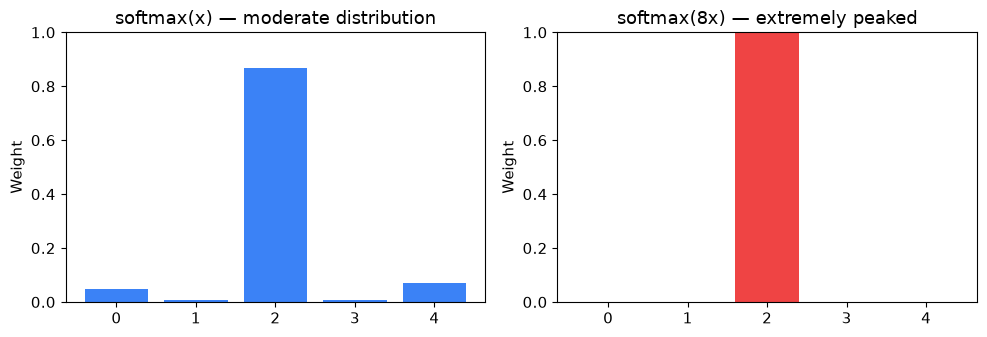

In [14]:
# Visualize the effect of scaling on softmax sharpness
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(range(5), soft_normal.numpy(), color=COLORS["blue"])
axes[0].set_title("softmax(x) — moderate distribution")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Weight")

axes[1].bar(range(5), soft_scaled.numpy(), color=COLORS["red"])
axes[1].set_title("softmax(8x) — extremely peaked")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Weight")

plt.tight_layout()
plt.show()

### Reason 2 — The variance argument: Why specifically $\sqrt{d_k}$?

Assume each component of $q$ and $k$ is an independent random variable with approximately:

$$
\text{mean} = 0, \quad \text{variance} = 1
$$

The dot product between $q$ and $k$ is:

$$
q \cdot k = \sum_{i=1}^{d_k} q_i k_i
$$

Each term $q_i k_i$ has:
- $\mathbb{E}[q_i k_i] = 0$ (product of zero-mean independent variables)
- $\text{Var}(q_i k_i) = 1$ (product of unit-variance independent variables)

Since there are $d_k$ such independent terms:

$$
\text{Var}(q \cdot k) \approx d_k
$$

**The variance of the dot product grows linearly with $d_k$.** Larger dimensions → larger scores → sharper softmax.

Dividing by $\sqrt{d_k}$ restores unit variance:

$$
\text{Var}\!\left(\frac{q \cdot k}{\sqrt{d_k}}\right) = \frac{\text{Var}(q \cdot k)}{d_k} \approx \frac{d_k}{d_k} = 1
$$

Let's verify this experimentally:

In [15]:
# Demonstrate that scaling by sqrt(d_k) stabilizes variance
torch.manual_seed(42)

dims = [5, 20, 50, 100]
n_trials = 10000

results = []
for d in dims:
    q_rand = torch.randn(n_trials, d)   # (n_trials, d)
    k_rand = torch.randn(n_trials, d)   # (n_trials, d)
    
    # Dot product: sum across dimension d
    dots = (q_rand * k_rand).sum(dim=1)  # (n_trials,)
    
    var_before = dots.var().item()
    var_after  = (dots / math.sqrt(d)).var().item()
    results.append([str(d), f"{var_before:.2f}", f"{var_after:.2f}"])

print_table(["d_k", "Var(q·k)", "Var(q·k / √d_k)"], results)

d_k | Var(q·k) | Var(q·k / √d_k)
----+----------+----------------
5   | 5.09     | 1.02           
20  | 20.11    | 1.01           
50  | 51.01    | 1.02           
100 | 99.98    | 1.00           


> **Key idea:** Without scaling, the variance of dot-product scores grows with $d_k$. Dividing by $\sqrt{d_k}$ keeps the variance approximately 1 regardless of dimension, ensuring that softmax produces well-behaved gradients.

Notice how `Var(q·k)` grows roughly proportional to $d_k$, but `Var(q·k / √d_k)` stays close to 1.0 for all dimensions.

---

## 14. Softmax → Attention Weights (Single Query)

Let's first compute attention weights for *"journey"* only:

$$
\text{attention\_weights}_{\text{journey}} = \text{softmax}\!\left(\frac{q_{\text{journey}} K^T}{\sqrt{d_k}}\right)
$$

In [16]:
# Scale the scores for "journey"
scaled_scores_journey = attn_scores_journey / math.sqrt(d_k)

# Apply softmax across the key dimension
attn_weights_journey = torch.softmax(scaled_scores_journey, dim=-1)

print("Scaled scores (journey):  ", scaled_scores_journey)
print("Attention weights (journey):", attn_weights_journey)
print(f"Sum of weights: {attn_weights_journey.sum():.4f}")

Scaled scores (journey):   tensor([ 0.0063, -0.0655, -0.0637,  0.0156,  0.0763, -0.0417])
Attention weights (journey): tensor([0.1695, 0.1578, 0.1581, 0.1711, 0.1818, 0.1616])
Sum of weights: 1.0000


**Understanding `dim=-1`:**

- `dim=-1` means *"apply softmax across the last dimension."*
- For a tensor shaped `(6,)`, `dim=-1` is the only dimension — softmax runs over all 6 values.
- For the full attention matrix shaped `(6, 6)`, `dim=-1` means softmax is applied **independently to each row**.
- Each row then sums to 1 — it represents how much one query token attends to each key token.

---

## 15. Full Attention Weights Matrix

Apply scaling and softmax to the full score matrix:

In [17]:
attention_weights = torch.softmax(scaled_scores, dim=-1)  # (6, 6)

print("attention_weights.shape:", tuple(attention_weights.shape))
print()

# Display as labeled DataFrame
df_weights = pd.DataFrame(
    attention_weights.detach().numpy(),
    index=[f"{t} (Q)" for t in tokens],
    columns=[f"{t} (K)" for t in tokens],
)
print(df_weights.round(4))

attention_weights.shape: (6, 6)

             Your (K)  journey (K)  starts (K)  with (K)  one (K)  step (K)
Your (Q)       0.1763       0.1488      0.1512    0.1802   0.1872    0.1562
journey (Q)    0.1695       0.1578      0.1581    0.1711   0.1818    0.1616
starts (Q)     0.1678       0.1609      0.1607    0.1688   0.1785    0.1634
with (Q)       0.1687       0.1599      0.1601    0.1699   0.1785    0.1628
one (Q)        0.2178       0.0845      0.0944    0.2458   0.2482    0.1094
step (Q)       0.1827       0.1386      0.1426    0.1893   0.1969    0.1499


In [18]:
# Sanity check: each row should sum to 1
row_sums = attention_weights.sum(dim=-1)
print("Row sums:", row_sums)
assert torch.allclose(row_sums, torch.ones(6)), "Rows don't sum to 1!"
print("✓ All rows sum to 1")

Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
✓ All rows sum to 1


---

## 16. Visualize Attention Weights

A heatmap makes the attention pattern easy to read:
- **Row** = which token is asking (query)
- **Column** = which token is being attended to (key)
- **Color intensity** = how much attention is paid

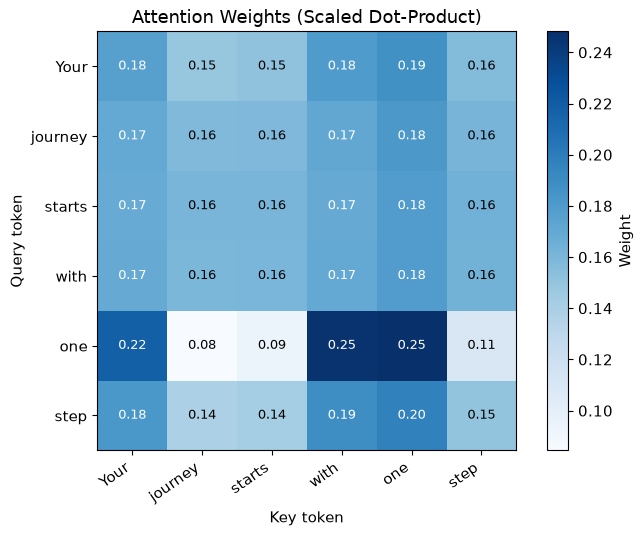

In [19]:
annotated_heatmap(
    attention_weights.detach().numpy(),
    row_labels=tokens,
    column_labels=tokens,
    title="Attention Weights (Scaled Dot-Product)",
    colorbar_label="Weight",
)

> **Reading the heatmap:** Pick any row — that token's query is being matched against all keys. The weights in that row tell you the relative importance of each token for building that query token's context vector.

**Concept check:** If position (2, 4) has a high weight, what does that mean in words?

---

## 17. Context Vectors — The Final Output

Now we arrive at the most important step.

- $Q$ and $K$ determined **where to pay attention** (the weights)
- $V$ contains **the information that is actually aggregated**

$$
\text{Context} = \text{Attention Weights} \times V
$$

**Dimension check:**
```text
Attention Weights : (6, 6)
V                 : (6, 2)
──────────────────────────
Context           : (6, 2)    ← one context vector per token
```

Each row of the context matrix is a **weighted sum of all value vectors**, where the weights come from the attention mechanism.

---

## 18. Manually Calculate "journey"'s Context Vector

Take the second row (index 1) of the attention weights — these are the weights that *"journey"* assigns to each token.

$$
\text{context}_{\text{journey}} = 
  w_{\text{Your}} \cdot v_{\text{Your}}
+ w_{\text{journey}} \cdot v_{\text{journey}}
+ w_{\text{starts}} \cdot v_{\text{starts}}
+ w_{\text{with}} \cdot v_{\text{with}}
+ w_{\text{one}} \cdot v_{\text{one}}
+ w_{\text{step}} \cdot v_{\text{step}}
$$

This is a **weighted average** of value vectors — tokens that received more attention contribute more to the context.

In [20]:
# Get journey's attention weights (row 1)
weights_journey = attention_weights[1]

print("Attention weights for 'journey':")
for i, token in enumerate(tokens):
    print(f"  w_{token:8s} = {weights_journey[i]:.4f}   ×   V_{token} = {V[i].tolist()}")

# Manual weighted sum
context_journey_manual = torch.zeros(d_out)
for i in range(len(tokens)):
    context_journey_manual += weights_journey[i] * V[i]

print(f"\ncontext_journey (manual) = {context_journey_manual}")

Attention weights for 'journey':
  w_Your     = 0.1695   ×   V_Your = [0.12421865016222, 0.3861830532550812]
  w_journey  = 0.1578   ×   V_journey = [0.8237103223800659, -0.45018020272254944]
  w_starts   = 0.1581   ×   V_starts = [0.751537024974823, -0.4544483423233032]
  w_with     = 0.1711   ×   V_with = [-0.31681588292121887, 0.6650383472442627]
  w_one      = 0.1818   ×   V_one = [0.9921295642852783, 0.9270651340484619]
  w_step     = 0.1616   ×   V_step = [1.0366202592849731, -0.3544842302799225]

context_journey (manual) = tensor([0.5636, 0.1477])


> **Key idea:** The context vector is *not* the original embedding with extra information appended. It is an entirely **new representation** formed from a weighted combination of the value vectors of all tokens in the sequence.

---

## 19. Matrix Form — All Context Vectors at Once

The exact same calculation for all tokens simultaneously:

In [21]:
context_vectors = attention_weights @ V   # (6, 6) @ (6, 2) → (6, 2)

print("context_vectors.shape:", tuple(context_vectors.shape))
print()
print("Context vectors:")
print(context_vectors)

context_vectors.shape: (6, 2)

Context vectors:
tensor([[0.5487, 0.1705],
        [0.5636, 0.1477],
        [0.5671, 0.1392],
        [0.5651, 0.1412],
        [0.4494, 0.3579],
        [0.5348, 0.1986]])


In [22]:
# Verify: row 1 of the matrix result matches our manual calculation
print("Matrix result (row 1): ", context_vectors[1])
print("Manual result:         ", context_journey_manual)
print("Match?", torch.allclose(context_vectors[1], context_journey_manual))

Matrix result (row 1):  tensor([0.5636, 0.1477])
Manual result:          tensor([0.5636, 0.1477])
Match? True


We've now completed the full pipeline manually. Each of the 6 input tokens has been transformed from a 3D embedding into a 2D context-aware representation.

```text
Input:   (6, 3)  →  Context:  (6, 2)
```

---

## 20. Implement `SelfAttentionV1` — Using `nn.Parameter`

Let's wrap everything into a reusable PyTorch module.

In [23]:
class SelfAttentionV1(nn.Module):
    """Self-attention with explicit nn.Parameter weight matrices."""
    
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.randn(d_in, d_out))  # (d_in, d_out)
        self.W_key   = nn.Parameter(torch.randn(d_in, d_out))  # (d_in, d_out)
        self.W_value = nn.Parameter(torch.randn(d_in, d_out))  # (d_in, d_out)
    
    def forward(self, X):
        # X: (seq_len, d_in)
        
        queries = X @ self.W_query   # (seq_len, d_out)
        keys    = X @ self.W_key     # (seq_len, d_out)
        values  = X @ self.W_value   # (seq_len, d_out)
        
        # Attention scores: (seq_len, seq_len)
        attn_scores = queries @ keys.T
        
        # Scale by sqrt(d_k)
        d_k = keys.shape[-1]
        scaled_scores = attn_scores / math.sqrt(d_k)
        
        # Softmax → attention weights: (seq_len, seq_len)
        attn_weights = torch.softmax(scaled_scores, dim=-1)
        
        # Context vectors: (seq_len, d_out)
        context = attn_weights @ values
        
        return context


print("SelfAttentionV1 defined.")

SelfAttentionV1 defined.


---

## 21. Verify `SelfAttentionV1`

In [24]:
torch.manual_seed(42)
attn_v1 = SelfAttentionV1(d_in=3, d_out=2)

context_v1 = attn_v1(inputs)

print(f"Input shape:  {tuple(inputs.shape)}")
print(f"Output shape: {tuple(context_v1.shape)}")
print()
print("Context vectors (V1):")
print(context_v1)

Input shape:  (6, 3)
Output shape: (6, 2)

Context vectors (V1):
tensor([[0.5487, 0.1705],
        [0.5636, 0.1477],
        [0.5671, 0.1392],
        [0.5651, 0.1412],
        [0.4494, 0.3579],
        [0.5348, 0.1986]], grad_fn=<MmBackward0>)


Each of the 6 input tokens now has a 2D context-aware representation. The module encapsulates the full pipeline:

```text
Input (6, 3)  →  SelfAttentionV1  →  Context (6, 2)
```

**Concept check:** How many trainable parameters does this module have?

In [25]:
# Count trainable parameters
total_params = sum(p.numel() for p in attn_v1.parameters())
print(f"Total trainable parameters: {total_params}")
print(f"  W_query: {attn_v1.W_query.numel()} = {d_in} × {d_out}")
print(f"  W_key:   {attn_v1.W_key.numel()} = {d_in} × {d_out}")
print(f"  W_value: {attn_v1.W_value.numel()} = {d_in} × {d_out}")
print(f"  Total:   3 × {d_in}×{d_out} = {3 * d_in * d_out}")

Total trainable parameters: 18
  W_query: 6 = 3 × 2
  W_key:   6 = 3 × 2
  W_value: 6 = 3 × 2
  Total:   3 × 3×2 = 18


---

## 22. Implement `SelfAttentionV2` — Using `nn.Linear`

In practice, PyTorch developers use `nn.Linear` instead of raw `nn.Parameter` matrices.

**Why?**

| Feature | `nn.Parameter` | `nn.Linear` |
|---|---|---|
| Weight initialization | Manual (`torch.randn`) | Uses Kaiming uniform by default |
| Bias term | Must add manually | Built-in (can disable with `bias=False`) |
| Framework integration | Low-level | Standard layer, better tooling support |

With `bias=False`, `nn.Linear(d_in, d_out)` performs the same mathematical operation as multiplying by a `(d_in, d_out)` matrix.

> **Note:** `nn.Linear` stores its weight as shape `(d_out, d_in)` internally and transposes it during the forward pass, but the effect is the same: input `(*, d_in)` → output `(*, d_out)`.

In [26]:
class SelfAttentionV2(nn.Module):
    """Self-attention using nn.Linear (standard practice)."""
    
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)
    
    def forward(self, X):
        # X: (seq_len, d_in)
        
        queries = self.W_query(X)   # (seq_len, d_out)
        keys    = self.W_key(X)     # (seq_len, d_out)
        values  = self.W_value(X)   # (seq_len, d_out)
        
        # Attention scores: (seq_len, seq_len)
        attn_scores = queries @ keys.T
        
        # Scale and normalize
        d_k = keys.shape[-1]
        attn_weights = torch.softmax(attn_scores / math.sqrt(d_k), dim=-1)
        
        # Context vectors: (seq_len, d_out)
        context = attn_weights @ values
        
        return context


print("SelfAttentionV2 defined.")

SelfAttentionV2 defined.


---

## 23. Compare Version 1 and Version 2

In [27]:
torch.manual_seed(42)
attn_v1 = SelfAttentionV1(d_in=3, d_out=2)

torch.manual_seed(42)
attn_v2 = SelfAttentionV2(d_in=3, d_out=2)

context_v1 = attn_v1(inputs)
context_v2 = attn_v2(inputs)

print("V1 output:")
print(context_v1.detach())
print("\nV2 output:")
print(context_v2.detach())
print(f"\nOutputs identical? {torch.allclose(context_v1, context_v2)}")

V1 output:
tensor([[0.5487, 0.1705],
        [0.5636, 0.1477],
        [0.5671, 0.1392],
        [0.5651, 0.1412],
        [0.4494, 0.3579],
        [0.5348, 0.1986]])

V2 output:
tensor([[0.3354, 0.2189],
        [0.3293, 0.2198],
        [0.3299, 0.2198],
        [0.3360, 0.2186],
        [0.3377, 0.2191],
        [0.3312, 0.2198]])

Outputs identical? False


**Why the outputs differ:**

- V1 initializes weights with `torch.randn(d_in, d_out)` — shape `(3, 2)`
- V2 uses `nn.Linear`, which internally stores weight as `(d_out, d_in)` shape `(2, 3)` and uses Kaiming uniform initialization

The weights are **initialized differently**, so the outputs differ. However, both modules implement the **exact same mathematical operation**: a linear projection followed by scaled dot-product attention.

After training, both would converge to the same learned behavior. `SelfAttentionV2` is preferred in practice because `nn.Linear` provides standard initialization and integrates naturally with the PyTorch ecosystem.

---

## 24. Understanding Query, Key, and Value Intuitively

The names Q, K, V come from a **database / information retrieval analogy**:

### Query — "What am I looking for?"

Each token generates a query that encodes what kind of information it needs from the rest of the sequence. Think of it as a search query typed into a search engine.

### Key — "What do I have to offer for matching?"

Each token also generates a key that advertises its content for matching purposes. Think of it as the index entry in a search engine's database.

### Value — "What information do I actually carry?"

Each token generates a value that contains the actual information to be aggregated. Think of it as the document content retrieved after a search match.

---

**The two-stage process:**

```text
Stage 1:  Query + Key  →  determine relevance (attention weights)
Stage 2:  Weights + Value  →  retrieve and aggregate information (context vectors)
```

This separation is powerful because:
- **What to match on** (keys) can be different from **what to retrieve** (values)
- The model can learn to search for one kind of feature while combining a completely different kind of feature

For example, *"journey"* might use its query to find tokens related to *actions* (matching on keys), but the values it retrieves might encode *temporal* or *sequential* information — something entirely different from what was matched on.

---

## 25. The Complete Formula — Scaled Dot-Product Attention

Everything we built reduces to one elegant formula:

$$
\boxed{\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^T}{\sqrt{d_k}}\right) V}
$$

Mapping each part to what we implemented:

| Formula component | Meaning | Shape |
|---|---|---|
| $QK^T$ | Raw attention scores — dot-product compatibility | `(n, n)` |
| $/ \sqrt{d_k}$ | Scaling — stabilize the variance | `(n, n)` |
| $\text{softmax}(\cdot)$ | Normalize each row to a probability distribution | `(n, n)` |
| $(\cdots) V$ | Weighted aggregation of value vectors | `(n, d_{\text{out}})` |

**Why is it called "Scaled Dot-Product Attention"?**

1. **Dot-Product** — because $Q$ and $K$ are combined using dot products ($QK^T$)
2. **Scaled** — because the result is divided by $\sqrt{d_k}$

---

## 26. Final End-to-End Implementation with Assertions

One clean implementation that ties everything together:

In [ ]:
class SelfAttention(nn.Module):
    """Scaled Dot-Product Self-Attention.
    
    Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V
    """
    
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)
    
    def forward(self, X):
        queries = self.W_query(X)                                # (seq_len, d_out)
        keys    = self.W_key(X)                                  # (seq_len, d_out)
        values  = self.W_value(X)                                # (seq_len, d_out)
        
        attn_scores  = queries @ keys.T                          # (seq_len, seq_len)
        attn_weights = torch.softmax(
            attn_scores / math.sqrt(keys.shape[-1]), dim=-1      # (seq_len, seq_len)
        )
        context = attn_weights @ values                          # (seq_len, d_out)
        
        return context


print("SelfAttention (final) defined.")

In [ ]:
torch.manual_seed(42)
attention = SelfAttention(d_in=3, d_out=2)

# Run the full pipeline
context = attention(inputs)

print(f"Input:   {tuple(inputs.shape)}")
print(f"Output:  {tuple(context.shape)}")
print()
print("Context vectors:")
print(context)

In [ ]:
# ─── Shape assertions ───
# Re-run the forward pass with intermediate results for verification
torch.manual_seed(42)
attn_check = SelfAttention(d_in=3, d_out=2)

queries = attn_check.W_query(inputs)
keys    = attn_check.W_key(inputs)
values  = attn_check.W_value(inputs)
attn_scores  = queries @ keys.T
attn_weights = torch.softmax(attn_scores / math.sqrt(keys.shape[-1]), dim=-1)
context_out  = attn_weights @ values

assert queries.shape == (6, 2),       f"Expected (6,2), got {queries.shape}"
assert keys.shape == (6, 2),          f"Expected (6,2), got {keys.shape}"
assert values.shape == (6, 2),        f"Expected (6,2), got {values.shape}"
assert attn_scores.shape == (6, 6),   f"Expected (6,6), got {attn_scores.shape}"
assert attn_weights.shape == (6, 6),  f"Expected (6,6), got {attn_weights.shape}"
assert context_out.shape == (6, 2),   f"Expected (6,2), got {context_out.shape}"

# Verify attention weights sum to 1 per row
assert torch.allclose(
    attn_weights.sum(dim=-1), torch.ones(6)
), "Attention weights don't sum to 1!"

print("✓ All shape assertions passed")
print("✓ All attention weight rows sum to 1")

---

## 27. Dimension Cheat Sheet

Keep this table handy — it summarizes every tensor in the pipeline.

| Object | Shape | Notes |
|---|---|---|
| Input $X$ | `(6, 3)` | 6 tokens × 3D embedding ($d_{\text{in}} = 3$) |
| $W_Q$ | `(3, 2)` | Projects from $d_{\text{in}}$ to $d_{\text{out}}$ |
| $W_K$ | `(3, 2)` | Same shape as $W_Q$ |
| $W_V$ | `(3, 2)` | Same shape as $W_Q$ |
| $Q$ (queries) | `(6, 2)` | One query per token |
| $K$ (keys) | `(6, 2)` | One key per token |
| $V$ (values) | `(6, 2)` | One value per token |
| $K^T$ | `(2, 6)` | Transposed for dot products |
| $QK^T$ (scores) | `(6, 6)` | Every query–key pair |
| Attention weights | `(6, 6)` | After scale + softmax; rows sum to 1 |
| Context | `(6, 2)` | Weighted sum of values; final output |

---

## 28. Final Concept Summary

```text
X
│
├── Q = X W_Q
├── K = X W_K
└── V = X W_V
      │
      ▼
Scores = Q K^T
      │
      ▼
Scaled Scores = Scores / √d_k
      │
      ▼
Attention Weights = softmax(Scaled Scores)
      │
      ▼
Context = Attention Weights × V
```

> Each token creates a **query** describing what it is looking for, **keys** describing what each token offers for matching, and **values** containing the information that will ultimately be combined. The query–key interaction determines the weights, and those weights are used to combine the values into a context-aware representation.

In actual Transformer training, $W_Q$, $W_K$, and $W_V$ are learned through **backpropagation** as part of a larger neural network. The initial random values are only initialization — the model discovers the optimal projections during training.

---

### What's next?

This notebook covered **one attention head** without any masking. The next two steps are:

1. **Causal attention** — prevent tokens from attending to future positions (required for autoregressive language models like GPT)
2. **Multi-head attention** — run multiple attention heads in parallel, each learning different relationship patterns, then combine their outputs

Both build directly on the Scaled Dot-Product Attention formula we derived here.

---

## Exercises

Test your understanding before moving on.

1. **Dimension change:** What happens to the output dimension if `d_out` changes from 2 to 4? What shapes change in the pipeline?

2. **Why transpose?** Why is $K$ transposed when calculating $QK^T$? What would go wrong if we computed $QK$ instead?

3. **Row sums:** Why does each row of the attention weight matrix sum to 1? Which operation guarantees this?

4. **Scaling:** Why do we divide by $\sqrt{d_k}$ and not by $d_k$ or some other value?

5. **V's role:** What role does $V$ play that $Q$ and $K$ do not? Why is this separation useful?

---

<details>
<summary><strong>Click to reveal solutions</strong></summary>

**1. Dimension change:**

With `d_out = 4`:
- $W_Q, W_K, W_V$ become `(3, 4)` instead of `(3, 2)`
- $Q, K, V$ become `(6, 4)` instead of `(6, 2)`
- $K^T$ becomes `(4, 6)`
- $QK^T$ stays `(6, 6)` — the attention score matrix is always `(seq_len, seq_len)`
- Attention weights stay `(6, 6)`
- Context becomes `(6, 4)` instead of `(6, 2)`

The attention pattern shape is independent of `d_out`.

---

**2. Why transpose?**

Matrix multiplication requires the inner dimensions to match. $Q$ is `(6, 2)` and $K$ is `(6, 2)`. The operation $QK$ would try to multiply `(6, 2) @ (6, 2)`, which fails because the inner dimensions (2 and 6) don't match. Transposing gives $K^T$ as `(2, 6)`, so `(6, 2) @ (2, 6) = (6, 6)` — one score per query–key pair.

---

**3. Row sums:**

The **softmax** function guarantees this. Softmax converts any vector of real numbers into a probability distribution: all values become positive and sum to 1. Applied with `dim=-1`, it normalizes each row independently.

---

**4. Scaling:**

The variance of a dot product between two random vectors grows proportional to $d_k$ (the number of summed terms). Dividing by $\sqrt{d_k}$ restores unit variance: $\text{Var}(q \cdot k / \sqrt{d_k}) \approx d_k / d_k = 1$. Dividing by $d_k$ would over-correct (variance would become $1/d_k$, shrinking the scores too much).

---

**5. V's role:**

$Q$ and $K$ determine **where** to attend (they compute the attention weights via compatibility scores). $V$ determines **what information** gets aggregated. This separation is powerful: the features used for matching can be entirely different from the features that are combined. The model can learn to match on one type of pattern while retrieving a completely different type of information.

</details>